# Business Understanding

## Project Domain

## Problem Statements

## Goals

## Solution Statements

# Data Understanding

## Import data dari kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dwirama21","key":"2e49dcc7cf403e23ebf9a32a44f7d021"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [4]:
!kaggle datasets download -d andrewmvd/autism-screening-on-adults

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/autism-screening-on-adults
License(s): other


In [5]:
!mkdir autism-screening-on-adults
!unzip autism-screening-on-adults.zip -d autism-screening-on-adults
!ls autism-screening-on-adults

Archive:  autism-screening-on-adults.zip
  inflating: autism-screening-on-adults/autism_screening.csv  
autism_screening.csv


## Import Library yang dibutuhkan

In [419]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model

## Exploratory Data Analysis

In [420]:
df = pd.read_csv('/content/autism-screening-on-adults.zip')

In [421]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2.0,18 and more,?,NO


In [422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    object 
 12  ethnicity        704 non-null    object 
 13  jundice          704 non-null    object 
 14  austim           704 non-null    object 
 15  contry_of_res    704 non-null    object 
 16  used_app_before  704 non-null    object 
 17  result          

In [423]:
df['age'].value_counts()

,count
age,
21.0,49
20.0,46
22.0,37
23.0,37
19.0,35
24.0,34
18.0,31
27.0,31
30.0,30


<Axes: ylabel='age'>

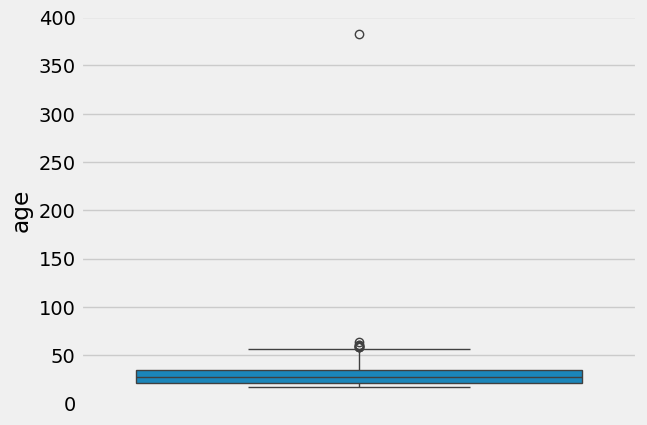

In [424]:
sns.boxplot(df['age'])

In [425]:
df = df.drop(df[df['age'] == 383].index)

In [426]:
df['age'].value_counts()

,count
age,
21.0,49
20.0,46
23.0,37
22.0,37
19.0,35
24.0,34
27.0,31
18.0,31
30.0,30


<Axes: ylabel='age'>

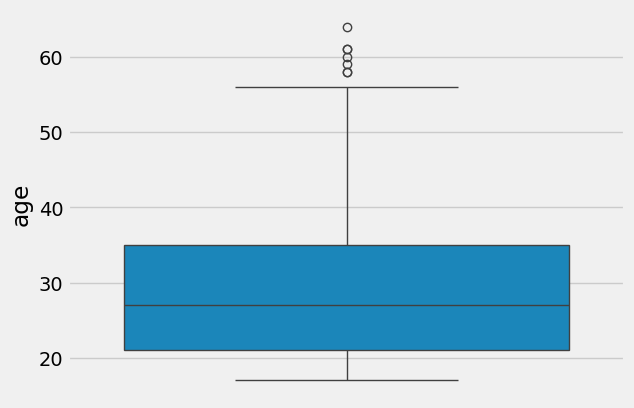

In [427]:
sns.boxplot(df['age'])

In [428]:
df['age'].isnull().sum()

np.int64(2)

In [429]:
df['age'] = df['age'].fillna(round(df['age'].mean()))

In [430]:
df['age'].isnull().sum()

np.int64(0)

In [431]:
df['gender'].value_counts()

,count
gender,
m,367
f,336


In [432]:
df['ethnicity'].value_counts()

,count
ethnicity,
White-European,233
Asian,123
?,95
Middle Eastern,92
Black,43
South Asian,36
Others,30
Latino,20
Hispanic,13


In [433]:
df['ethnicity'] = df['ethnicity'].replace('?', 'others')

In [434]:
df['ethnicity'].value_counts()

,count
ethnicity,
White-European,233
Asian,123
others,96
Middle Eastern,92
Black,43
South Asian,36
Others,30
Latino,20
Hispanic,13


In [435]:
df['jundice'].value_counts()

,count
jundice,
no,634
yes,69


In [436]:
df['austim'].value_counts()

,count
austim,
no,612
yes,91


In [477]:
df['contry_of_res'].value_counts()

,count
contry_of_res,
United States,113
United Arab Emirates,82
India,81
New Zealand,80
United Kingdom,77
...,...
Angola,1
Azerbaijan,1
Iraq,1


In [438]:
df['used_app_before'].value_counts()

,count
used_app_before,
no,691
yes,12


In [439]:
df['age_desc'].value_counts()

,count
age_desc,
18 and more,703


In [440]:
df['relation'].value_counts()

,count
relation,
Self,521
?,95
Parent,50
Relative,28
Others,5
Health care professional,4


In [441]:
df['relation'] = df['relation'].replace('?', 'Others')
df['relation'].value_counts()

,count
relation,
Self,521
Others,100
Parent,50
Relative,28
Health care professional,4


In [442]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
NO,514
YES,189


In [443]:
#using plotly to visualize the number of autistic and non-autistic patients
fig = px.histogram(df, x='Class/ASD')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [444]:
#using plotly to visualize the average age of autistic and non-autistic patients
fig = px.bar(df.groupby('Class/ASD', as_index=False).agg({'age':'mean'}),
             x='Class/ASD',
             y='age',
             color='Class/ASD',
             title='Average Age of Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Average Age of Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [445]:
#using plotly to visualize the count of the gender
fig = px.histogram(df, x='gender')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of Males and Females </b>', title_x=0.5)

# Show the plot
fig.show()

In [446]:
#using plotly to visualize the count of the males and females for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'gender']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='gender',
             title='Count of Males and Females of Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of Males and Females of Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [447]:
# Count of Autistic Patients in Different Countries
filtered_df = df[df['Class/ASD'] == "YES"]

# Create a histogram
fig = px.histogram(filtered_df, x='contry_of_res')

# Update layout to center the title and set the category order
fig.update_layout(
    title_text='<b>Count of Autistic Patients in Different Countries</b>',
    title_x=0.5,
    xaxis=dict(categoryorder='total descending')
)

# Show the plot
fig.show()

In [448]:
#using plotly to visualize the count of age_desc for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'age_desc']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='age_desc',
             title='Count of People over 18 for Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People over 18 for Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [449]:
#using plotly to visualize 'jundice' with pie chart
fig = px.pie(df, names='jundice')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People with Jaundice</b>', title_x=0.5)

# Show the plot
fig.show()

In [450]:
#using plotly to visualize the count of people with jundice for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'jundice']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='jundice',
             title='Count of people with jundice for Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of people with jundice for Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [451]:
#using plotly to visualize 'used_app_before' with pie chart
fig = px.pie(df, names='used_app_before')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People who used the screening App before</b>', title_x=0.5)

# Show the plot
fig.show()

In [452]:
#using plotly to visualize used_app_before for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'used_app_before']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='used_app_before',
             title='Count of People who used the screening App before for Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People who used the screening App before for Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

# Data Preparation

In [453]:
df = df.drop('age_desc', axis=1)

In [454]:
X = df.drop('Class/ASD', axis=1)
y = df['Class/ASD']

In [455]:
# Columns to apply label encoding
cols_to_encode = ['gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'relation']

# Apply label encoding to X
label_encoder_X = LabelEncoder()
for col in cols_to_encode:
    X[col] = label_encoder_X.fit_transform(X[col])

# Apply label encoding to y
label_encoder_y = LabelEncoder()
y = label_encoder_y.fit_transform(y)

In [456]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [457]:
print(f"Shape of X_train is: {X_train.shape}")
print(f"Shape of Y_train is: {y_train.shape}\n")
print(f"Shape of X_test is: {X_test.shape}")
print(f"Shape of Y_test is: {y_test.shape}")

Shape of X_train is: (562, 19)
Shape of Y_train is: (562,)

Shape of X_test is: (141, 19)
Shape of Y_test is: (141,)


# Modeling

In [458]:
model = Sequential([
        Dense(10, activation='relu', input_dim=19),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [459]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [460]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297 (1.16 KB)

 Trainable params: 297 (1.16 KB)

 Non-trainable params: 0 (0.00 B)

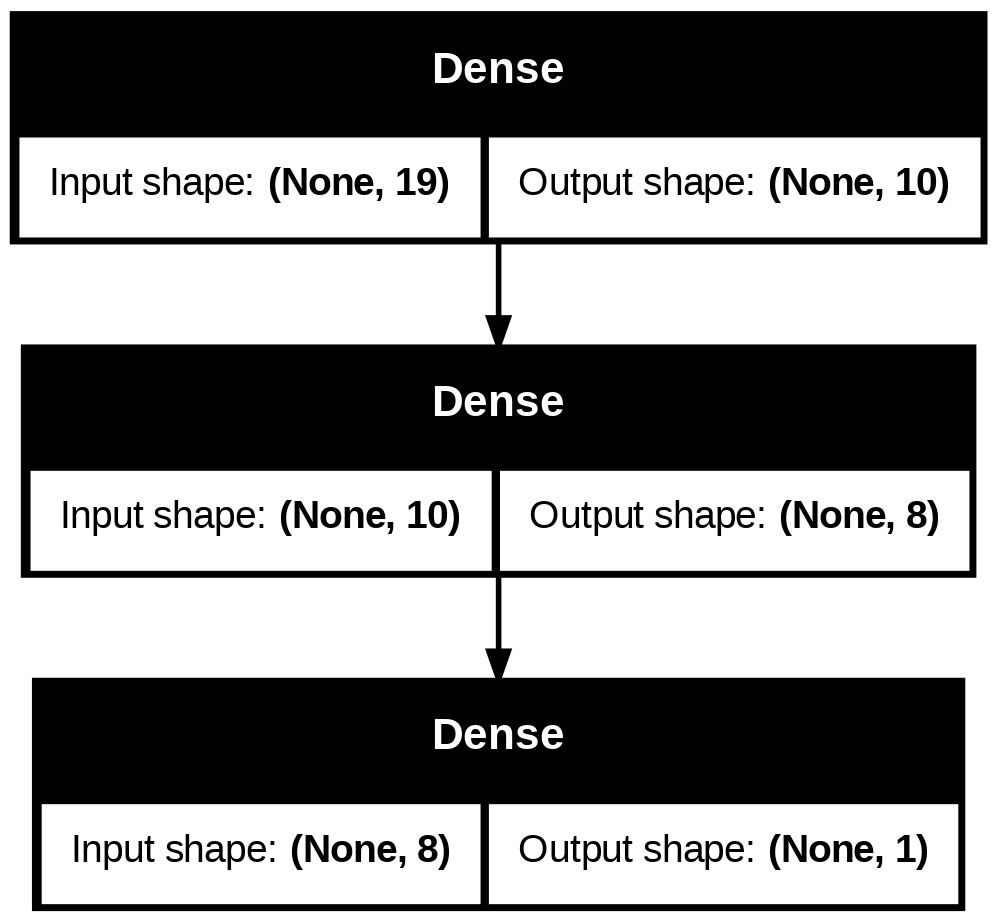

In [461]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [462]:
history = model.fit(X_train, y_train, epochs=150, validation_split=0.25)

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5651 - loss: 1.1657 - val_accuracy: 0.5390 - val_loss: 0.9389
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5587 - loss: 0.8987 - val_accuracy: 0.6525 - val_loss: 0.6756
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6644 - loss: 0.7134 - val_accuracy: 0.6738 - val_loss: 0.5701
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6828 - loss: 0.6021 - val_accuracy: 0.6667 - val_loss: 0.5395
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6745 - loss: 0.5705 - val_accuracy: 0.6950 - val_loss: 0.5223
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6328 - loss: 0.5891 - val_accuracy: 0.7021 - val_loss: 0.5129
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7288 - loss: 0.5368 - val_accuracy: 0.7092 - val_loss: 0.4946
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7291 - loss: 0.5213 - val_accuracy: 0.723

# Evaluation

In [463]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8827 - loss: 0.2053 
Akurasi Model: 0.8865
Loss Model: 0.2084


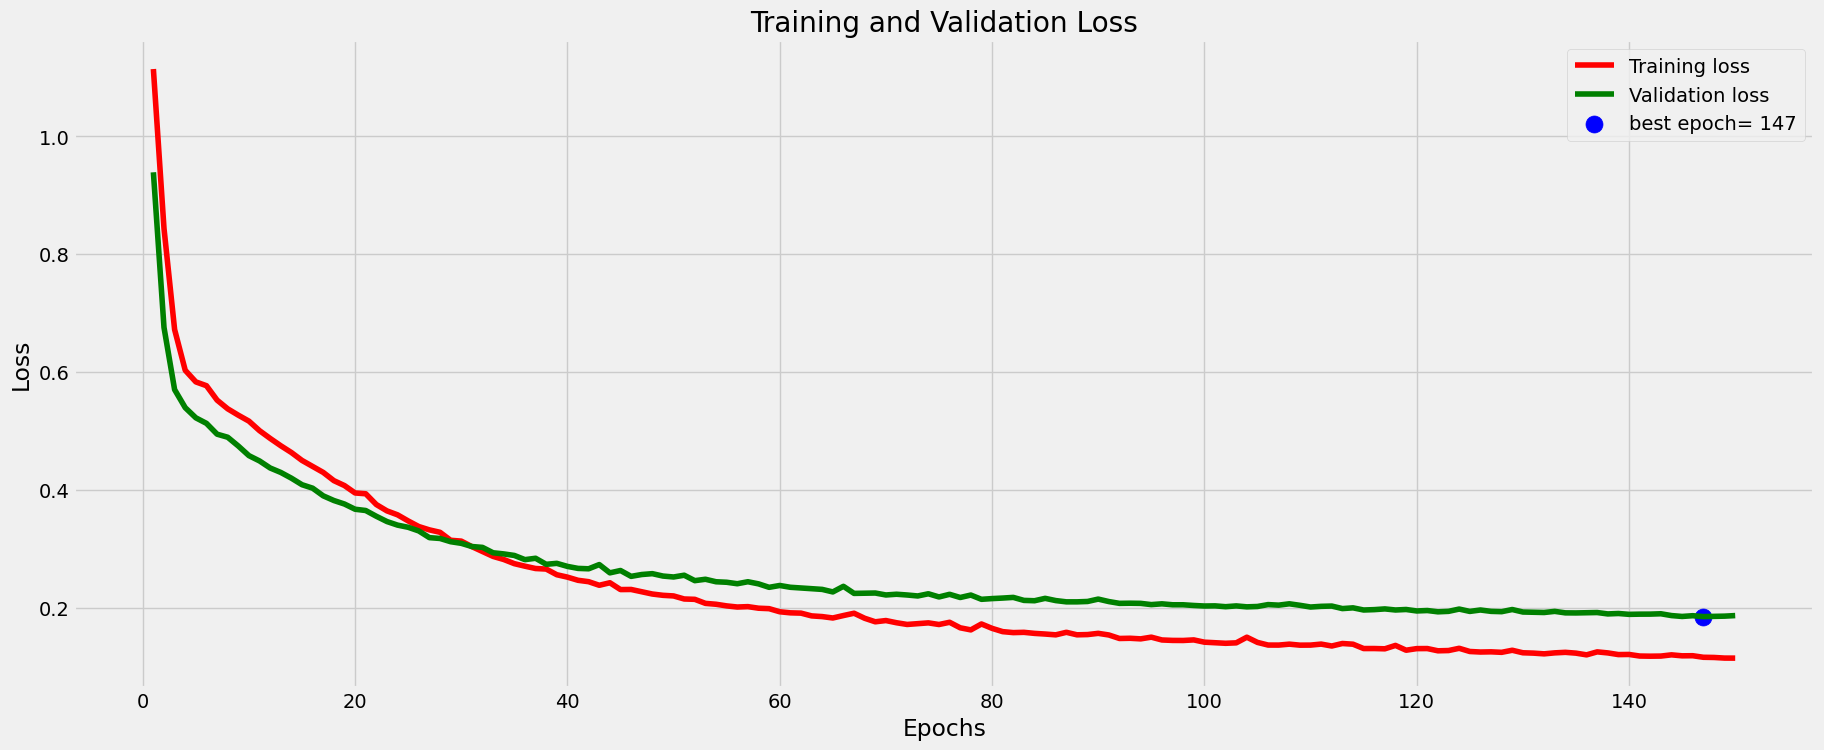

In [464]:
tr_loss = history.history['loss']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

Epochs = [i+1 for i in range(len(tr_loss))]
loss_label = f'best epoch= {str(index_loss + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

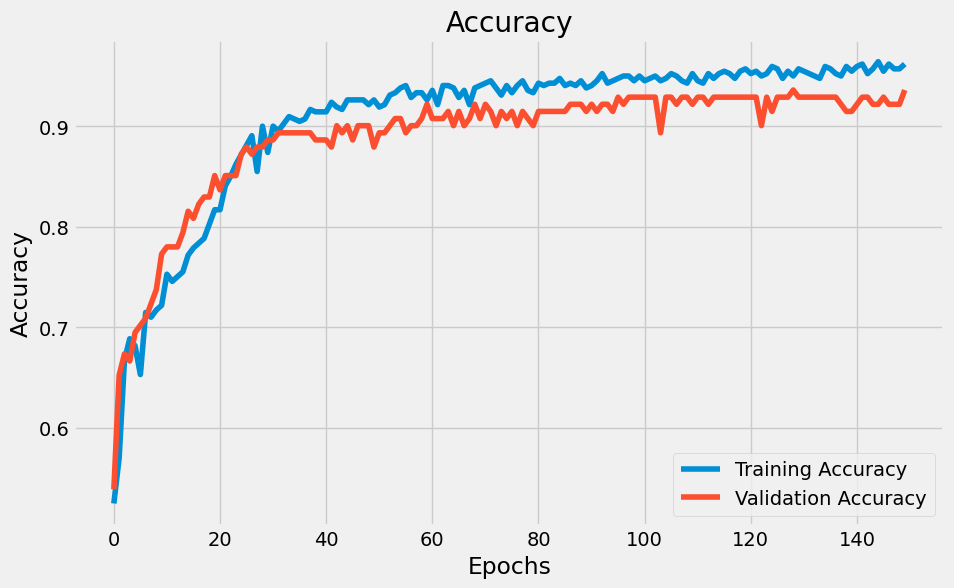

In [465]:
plt.figure(figsize=(10, 6))
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


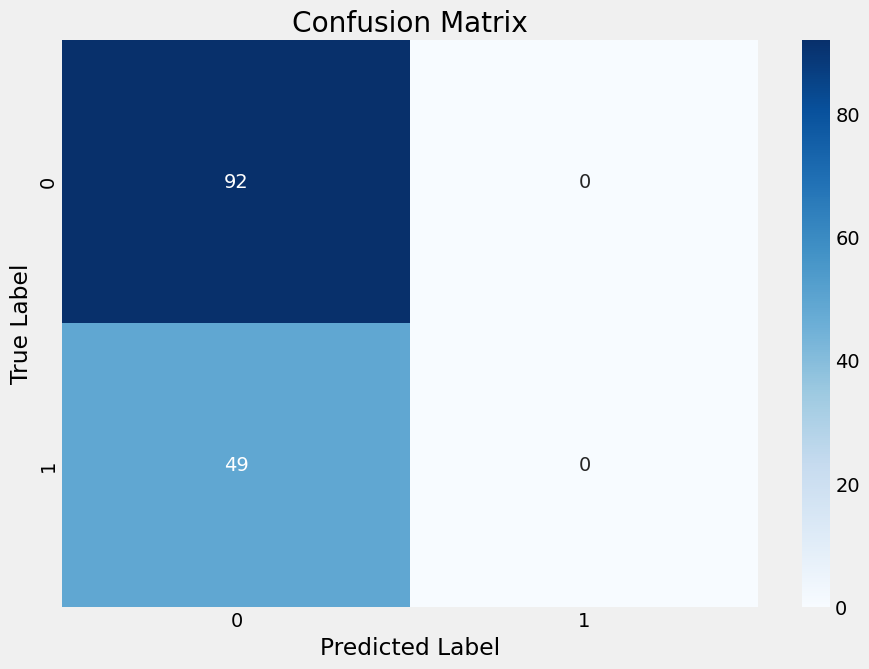

Classification Report:
              precision    recall  f1-score   support

           0       0.65      1.00      0.79        92
           1       0.00      0.00      0.00        49

    accuracy                           0.65       141
   macro avg       0.33      0.50      0.39       141
weighted avg       0.43      0.65      0.52       141



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [466]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes, zero_division='warn'))

# Deployment

## Model Simulation

In [471]:
sample_input = np.array([[25, 1, 4, 0, 1, 10, 1, 0, 3, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1]])
sample_input_df = pd.DataFrame(sample_input, columns=X.columns)

In [472]:
predicted_prob = model.predict(sample_input_df)[0][0]
predicted_class = 1 if predicted_prob >= 0.5 else 0
predicted_label = label_encoder_y.inverse_transform([predicted_class])[0]
print(f"Hasil prediksi: {predicted_label} (probabilitas = {predicted_prob:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Hasil prediksi: NO (probabilitas = 0.01)


## Save Model

In [473]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('autism-screening-on-adults.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpi4x9cv97'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 19), dtype=tf.float32, name='keras_tensor_24')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138352438252880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138352438250576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138352438248464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138352438251728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138352438248080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138352438249808: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [480]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(label_encoder_y, "label_encoder_y.pkl")

['label_encoder_y.pkl']